***Last update/compute : Computed on the 21-03-2025***

# Notebook for foundation inference

## Clinical embeddings

Initial commit : `0a572e7eb7cfba657aae4c78b064940afe155bcc`

Fixed made : 
- Removed `patient_id` from `num_features` (Commit : `40e0f07`)
- Removed `gbm_df.fillna("Unk", inplace = True)` (Commit : `6641f35`)



In [1]:
from foundation import clinical

In [2]:
clinical_embeddings = clinical.pipeline_clinical(True, mode='new', verbose=True)

Preparing Data...
Imputing numerical features...
Scaling numerical features...
Multi Component Analysis..
Retrieving column contributions..
Imputing targets..
Scaling targets..
norm_target_df            os_years  pfs_years
sample_id                     
HK_G_001a -0.221977   0.808799
HK_G_002a  0.454797   1.098956
HK_G_003a -0.032878   0.057366
HK_G_004a -0.456857  -0.861466
HK_G_005a  1.119627  -1.121863
...             ...        ...
HK_G_111b  0.297546  -0.303471
HK_G_112a  0.890719   1.761110
HK_G_113b  0.890719   1.761110
HK_G_114a  1.471948   2.564623
HK_G_115b  1.471948   2.564623

[114 rows x 2 columns]
target_df[cat_targets]            recurrent_sample  mgmt_promoter_methylation
sample_id                                             
HK_G_001a                 0                          1
HK_G_002a                 0                          0
HK_G_003a                 0                          0
HK_G_004a                 0                          0
HK_G_005a                 0 

/home/sagemaker-user/gbm_hackathon/foundation/clinical.py:298: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_df['mgmt_promoter_methylation'] = np.where(target_df['mgmt_promoter_methylation'] == 'Methylated', 1, 0)


In [3]:
clinical_embeddings.keys()

dict_keys(['settings', 'data', 'dataset'])

In [4]:
from gbmhackathon.s3_loader import write_s3
write_s3(obj=clinical_embeddings, save_name="new_clinical_emb_V1",folder="embedding_V1")

Object saved at s3://abstra-project-storage-lttemftb/1b75dc89-ad27-4a65-9e7f-877d1b4f36fc/embedding_V1/2025-05-20_21-35_new_clinical_emb_V1.pkl


## Phikon embeddings

Initial commit : `1fd001f3b5ec7f399bc0576356eb870d634f44f9`

Fix made : 
- `1454127` Update to fit s3 and pipeline
- `b8bc81c` Added garbage collection to embedding computation

In [1]:
from foundation import phikon as pk
from gbmhackathon.utils.he_functions import get_tif_bytes_io
from gbmhackathon.viz.visium_functions import get_slide_img

In [2]:
## Test on one embedding : 
processor_phikon, phikon = pk.setup_model("cpu")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.50, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [3]:
## To add in the lib
from gbmhackathon import MosaicDataset
def load_data() : 
    return MosaicDataset.load_tabular()["he"]["HE files"]

he_paths = load_data()
he_paths.head(2)

,path,patient id
Subject Id,,
HK_G_001a,03bb30aa-16ed-4b89-913e-fe009db2aabd/Visium/co...,HK_G_001
HK_G_002a,03bb30aa-16ed-4b89-913e-fe009db2aabd/Visium/co...,HK_G_002


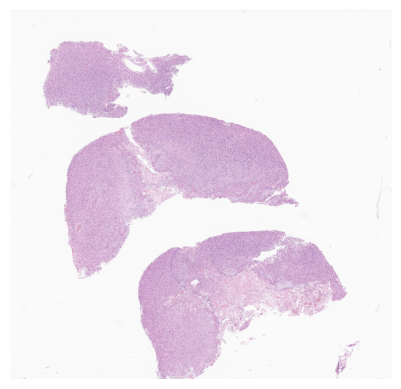

In [4]:
import matplotlib.pyplot as plt
## Loading one slide :
slide_idx = 12

#Visualisation :

slide_img = get_slide_img(slide_paths=he_paths, slide_idx= slide_idx)

fig, ax = plt.subplots()
ax.imshow(slide_img)
ax.set_axis_off()
plt.show()

In [6]:
from foundation import phikon

In [7]:
phikon_emb = phikon.pipeline_phikon(device = "cpu")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.50, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
86it [1:51:54, 78.08s/it] 


In [10]:
phikon_emb

{'HK_G_001a': tensor([[ 0.1128, -0.3456, -0.0970,  ...,  0.1700,  0.2618, -0.1506]]),
 'HK_G_002a': tensor([[ 0.0158, -0.4350, -0.0512,  ...,  0.0176,  0.0971, -0.1793]]),
 'HK_G_003a': tensor([[ 0.0783, -0.4527, -0.0748,  ...,  0.0886,  0.3966, -0.2469]]),
 'HK_G_004a': tensor([[-0.0197, -0.3094,  0.0533,  ...,  0.1443, -0.0992, -0.1470]]),
 'HK_G_005a': tensor([[ 0.1687, -0.1298,  0.0688,  ...,  0.2647,  0.0039,  0.2250]]),
 'HK_G_006a': tensor([[-0.0734, -0.3202,  0.0442,  ...,  0.3845,  0.1707,  0.0481]]),
 'HK_G_007a': tensor([[-0.0397, -0.2739, -0.2573,  ..., -0.0020, -0.2451, -0.1686]]),
 'HK_G_008a': tensor([[ 0.1686, -0.4579, -0.2023,  ...,  0.3308,  0.0276, -0.0008]]),
 'HK_G_009a': tensor([[-0.0279, -0.2264,  0.0667,  ...,  0.0915, -0.1707, -0.1094]]),
 'HK_G_010a': tensor([[-0.0557, -0.4239,  0.0391,  ...,  0.1990,  0.1307, -0.1487]]),
 'HK_G_011a': tensor([[ 0.0393, -0.3423, -0.0968,  ...,  0.0525, -0.0072, -0.0399]]),
 'HK_G_012a': tensor([[ 0.0600, -0.1486,  0.0172,  ...

In [12]:
write_s3(obj=phikon_emb, save_name="phikon_emb_V1",folder="embedding_V1")

Object saved at s3://abstra-project-storage-lttemftb/1b75dc89-ad27-4a65-9e7f-877d1b4f36fc/embedding_V1/2025-03-22_12-27_phikon_emb_V1.pkl


## Inference Spatial Transcriptomic

Inital commit of the functions used for the inference : `8ba1575ec6ede07eaccc8306c27dd1d2d1cef0a2`

Use at least 128Go de RAM 

In [1]:
from foundation import spatial_transcriptomic as sp_tr

In [2]:
# With default settings from initial commit
spatial_emb = sp_tr.pipeline_novae()

No sample list provided. Loading all samples.
Resolution of the spatial image to load:  hires
You can change the resolution by setting the resolution parameter using the resolution argument.
Loading Visium data, this can take few minutes...
Copying S3 : s3://pa-3dqtp2dd4t56b7jvg-bx3h881cqf4ushomn6mknw3cstocaeuw1b-s3alias/03bb30aa-16ed-4b89-913e-fe009db2aabd/Visium/spaceranger_count/HK_G_001a_vis/ to /tmp/visium_data
Copying S3 : s3://pa-3dqtp2dd4t56b7jvg-bx3h881cqf4ushomn6mknw3cstocaeuw1b-s3alias/03bb30aa-16ed-4b89-913e-fe009db2aabd/Visium/spaceranger_count/HK_G_002a_vis/ to /tmp/visium_data
Copying S3 : s3://pa-3dqtp2dd4t56b7jvg-bx3h881cqf4ushomn6mknw3cstocaeuw1b-s3alias/03bb30aa-16ed-4b89-913e-fe009db2aabd/Visium/spaceranger_count/HK_G_003a_vis/ to /tmp/visium_data
Copying S3 : s3://pa-3dqtp2dd4t56b7jvg-bx3h881cqf4ushomn6mknw3cstocaeuw1b-s3alias/03bb30aa-16ed-4b89-913e-fe009db2aabd/Visium/spaceranger_count/HK_G_004a_vis/ to /tmp/visium_data
Copying S3 : s3://pa-3dqtp2dd4t56b7jvg-bx3h

[INFO] (novae.utils._build) Computing graph on 1,462 cells (coord_type=grid, delaunay=False, radius=[0.0, 300.0], n_neighs=6)
[INFO] (novae.utils._build) Computing graph on 4,467 cells (coord_type=grid, delaunay=False, radius=[0.0, 300.0], n_neighs=6)
[INFO] (novae.utils._build) Computing graph on 2,876 cells (coord_type=grid, delaunay=False, radius=[0.0, 300.0], n_neighs=6)
[INFO] (novae.utils._build) Computing graph on 2,237 cells (coord_type=grid, delaunay=False, radius=[0.0, 300.0], n_neighs=6)
[INFO] (novae.utils._build) Computing graph on 3,589 cells (coord_type=grid, delaunay=False, radius=[0.0, 300.0], n_neighs=6)
[INFO] (novae.utils._build) Computing graph on 4,832 cells (coord_type=grid, delaunay=False, radius=[0.0, 300.0], n_neighs=6)
[INFO] (novae.utils._build) Computing graph on 4,773 cells (coord_type=grid, delaunay=False, radius=[0.0, 300.0], n_neighs=6)
[INFO] (novae.utils._build) Computing graph on 4,672 cells (coord_type=grid, delaunay=False, radius=[0.0, 300.0], n_ne

Computing representations:   0%|          | 0/3 [00:00<?, ?it/s]

Computing representations:   0%|          | 0/9 [00:00<?, ?it/s]

Computing representations:   0%|          | 0/6 [00:00<?, ?it/s]

...

Computing representations:   0%|          | 0/9 [00:00<?, ?it/s]

Computing representations:   0%|          | 0/10 [00:00<?, ?it/s]

Computing representations:   0%|          | 0/9 [00:00<?, ?it/s]

Computing representations:   0%|          | 0/9 [00:00<?, ?it/s]

Computing representations:   0%|          | 0/6 [00:00<?, ?it/s]

In [7]:
from gbmhackathon.s3_loader import write_s3
write_s3(obj=spatial_emb, save_name="spatial_emb_V1",folder="embedding_V1")

Object saved at s3://abstra-project-storage-lttemftb/1b75dc89-ad27-4a65-9e7f-877d1b4f36fc/embedding_V1/2025-03-23_18-32_spatial_emb_V1.pkl
